In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp


In [2]:
adata = sc.read_h5ad('../data/mtDNA_DSB_5k_clustered_manual_annotation_with_raw.h5ad')
CELLTYPES_TO_KEEP = [
    # --- Astrocytes ---
    "Telencephalon astrocytes",
    "Olfactory astrocytes",

    # --- Oligodendrocyte lineage ---
    "Mature oligodendrocytes",
    "Oligodendrocytes precursor cells",

    # --- Microglia ---
    "Microglia",
]  # e.g., ["Mature oligodendrocytes", "Microglia"]
adata = adata[adata.obs.cell_class.isin(CELLTYPES_TO_KEEP)]

In [3]:
# ==== Install (first time only) ====
# %pip install pandas numpy scipy anndata seaborn matplotlib pymc arviz tqdm

import numpy as np
import pandas as pd
import anndata as ad
from scipy.sparse import issparse
from tqdm import tqdm

# -----------------------------
# Configuration (edit these)
# -----------------------------
CELLTYPE_COL  = "cell_class"   # column in adata.obs
SAMPLE_COL    = "sample_id"
AGE_COL       = "age"
COND_COL      = "condition"    # (e.g., "control" vs "mtdsb")
LAYER_COUNTS  = "counts"       # if absent we'll use .X


# -----------------------------
# Utility: pseudobulk by groups
# -----------------------------
import numpy as np
import pandas as pd
import scipy.sparse as sp

# --- tell the code where the counts live ---
LAYER_COUNTS = "counts"   # change if your raw counts are in another layer
CELLTYPE_COL = "cell_class"   # or whatever column you’re using
SAMPLE_COL   = "sample_id"    # sample in .obs
AGE_COL      = "age"
COND_COL     = "condition"

def _as_csr(X):
    if sp.issparse(X):
        return X.tocsr()
    # dense -> csr
    return sp.csr_matrix(np.asarray(X), copy=False)

def pseudobulk_by_groups(adata, group_cols, layer=None, keep_celltypes=None):
    """
    Sum raw counts per (celltype, sample, age, condition).
    Returns:
      pb_counts : dense float32 array (n_groups x n_genes)
      groups_df : dataframe with group labels (n_groups x len(group_cols))
      var_names : pandas Index of gene names
    """
    # 0) pull matrix & obs
    if layer is None:
        X = _as_csr(adata.X)
    else:
        if layer not in adata.layers:
            raise ValueError(f"Layer '{layer}' not found in adata.layers")
        X = _as_csr(adata.layers[layer])

    obs = adata.obs.copy()

    # 1) optional filter of cell types
    if keep_celltypes is not None:
        obs = obs.loc[obs[CELLTYPE_COL].isin(keep_celltypes)]
        X   = X[obs.index, :]   # keep matrix aligned

    # 2) make sure group columns exist and are strings (avoid categorical gotchas)
    for c in group_cols:
        if c not in obs.columns:
            raise ValueError(f"Missing obs column: {c}")
    gdf = obs.loc[:, group_cols].astype(str).copy()

    # 3) build an integer code per group
    key = pd.MultiIndex.from_frame(gdf, names=group_cols)
    codes, uniques = pd.factorize(key, sort=True)

    # 4) aggregate counts by group using a sparse trick
    n_groups = len(uniques)
    n_genes  = X.shape[1]
    ones     = np.ones(X.shape[0], dtype=np.int64)
    row_idx  = codes  # which group each cell belongs to

    # make a sparse "group-by" matrix G (cells -> groups), then G @ X = group sums
    G = sp.csr_matrix((ones, (row_idx, np.arange(X.shape[0]))), shape=(n_groups, X.shape[0]))
    pb_sparse = G @ X
    pb_counts = np.asarray(pb_sparse.todense(), dtype=np.float32)

    # 5) unpack group labels
    groups_df = uniques.to_frame(index=False)  # columns=group_cols
    groups_df.columns = group_cols

    return pb_counts, groups_df.reset_index(drop=True), adata.var_names.copy()
# -----------------------------
# CPM + log1p normalization
# -----------------------------
def normalize_pseudobulk(pb_counts, axis=1, libsize_scale=1e6):
    """
    CPM + log1p with zero-safe division.
    axis=1 means library size per row (sample/group).
    """
    X = np.asarray(pb_counts, dtype=np.float32)
    if axis == 1:
        lib = X.sum(1, keepdims=True)  # group sums
    else:
        lib = X.sum(0, keepdims=True)

    # avoid /0 -> NaN
    lib = np.where(lib == 0.0, 1.0, lib)
    X_cpm = (X / lib) * libsize_scale
    return np.log1p(X_cpm).astype(np.float32)

# -----------------------------
# Long-format builder
# -----------------------------
def pseudobulk_to_long_with_celltype(pb_norm, groups_df, var_names,
                                     sample_col=SAMPLE_COL, age_col=AGE_COL,
                                     cond_col=COND_COL, celltype_col=CELLTYPE_COL,
                                     value_name="value"):
    """
    Returns tidy df: [sample, age, condition, cell_type, gene, value]
    """
    n_groups, n_genes = pb_norm.shape
    assert n_groups == len(groups_df), "shape mismatch"

    # build a dataframe carefully
    df = pd.DataFrame(pb_norm, columns=var_names)
    df.insert(0, sample_col, groups_df[sample_col].values)
    df.insert(1, age_col,    groups_df[age_col].values)
    df.insert(2, cond_col,   groups_df[cond_col].values)
    df.insert(3, celltype_col, groups_df[celltype_col].values)

    # wide -> long
    long = df.melt(
        id_vars=[sample_col, age_col, cond_col, celltype_col],
        var_name="gene", value_name=value_name
    )
    # ensure expected dtypes
    long[age_col] = long[age_col].astype(str)
    long[cond_col] = long[cond_col].astype(str)
    long[celltype_col] = long[celltype_col].astype(str)
    long[sample_col] = long[sample_col].astype(str)

    return long


In [4]:
# -----------------------------
# RUN pseudobulk
# -----------------------------
pb_counts, groups_df, var_names = pseudobulk_by_groups(
     adata, group_cols=(CELLTYPE_COL, SAMPLE_COL, AGE_COL, COND_COL),
     layer=LAYER_COUNTS if LAYER_COUNTS in adata.layers else None
 )
pb_norm = normalize_pseudobulk(pb_counts, axis=1)
df_long = pseudobulk_to_long_with_celltype(pb_norm, groups_df, var_names)

In [5]:
df_long

,sample_id,age,condition,cell_class,gene,value
0,RB4282,60,control,Mature oligodendrocytes,2610035D17Rik,4.598890
1,RB4350,60,control,Mature oligodendrocytes,2610035D17Rik,4.798055
2,RB4401,60,mtDSB,Mature oligodendrocytes,2610035D17Rik,4.939253
3,RB4403,60,mtDSB,Mature oligodendrocytes,2610035D17Rik,4.772352
4,RB4405,60,mtDSB,Mature oligodendrocytes,2610035D17Rik,5.025128
...,...,...,...,...,...,...
306055,RB4627,21,mtDSB,Telencephalon astrocytes,a,0.285294
306056,RB4630,21,mtDSB,Telencephalon astrocytes,a,0.255448
306057,RB4653,21,mtDSB,Telencephalon astrocytes,a,0.262754
306058,RB4658,21,control,Telencephalon astrocytes,a,0.847408


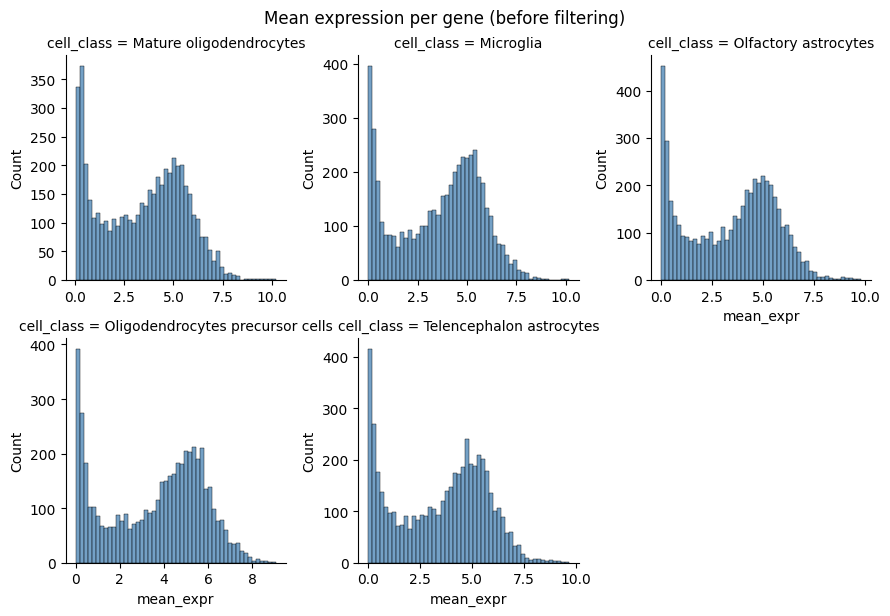

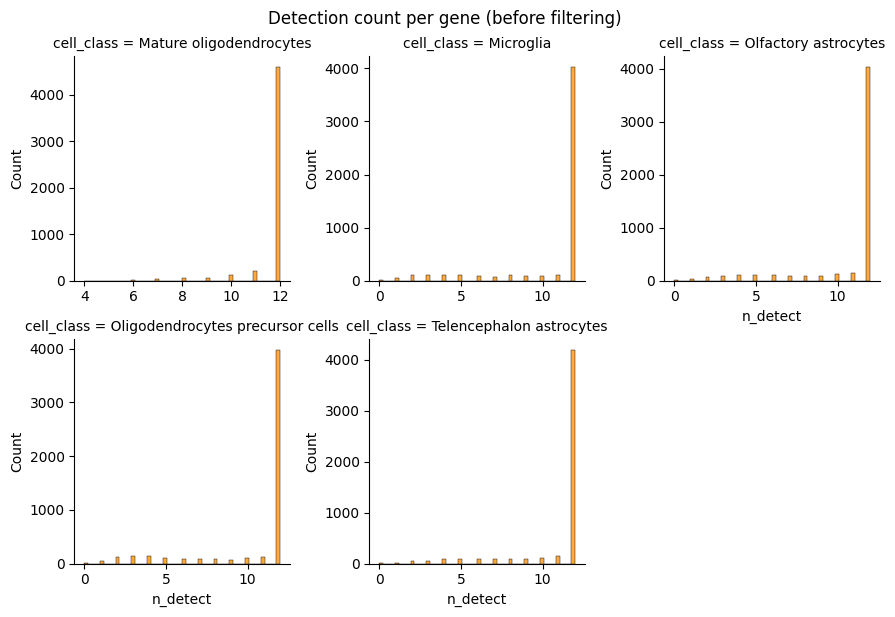

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# compute stats per gene and cell type
stats_all = (
    df_long
    .groupby(["cell_class", "gene"])
    .agg(
        mean_expr=("value", "mean"),
        n_detect=("value", lambda x: (x > 0).sum())
    )
    .reset_index()
)

# Plot distributions per cell type
g = sns.FacetGrid(stats_all, col="cell_class", col_wrap=3, sharex=False, sharey=False)
g.map(sns.histplot, "mean_expr", bins=50, color="steelblue")
g.fig.suptitle("Mean expression per gene (before filtering)", y=1.02)
plt.show()

g = sns.FacetGrid(stats_all, col="cell_class", col_wrap=3, sharex=False, sharey=False)
g.map(sns.histplot, "n_detect", bins=50, color="darkorange")
g.fig.suptitle("Detection count per gene (before filtering)", y=1.02)
plt.show()

In [7]:
# thresholds (edit to taste)
MIN_MEAN   = 3     # per (cell_type, gene) mean expression on log1p-CPM scale
MIN_DET    = 3       # gene must be detected (>0) in at least N samples within a cell type

def filter_low_genes(df_long, min_mean=MIN_MEAN, min_detect=MIN_DET):
    kept = []
    for ct, dfc in df_long.groupby("cell_class"):
        stats = (dfc
                 .groupby("gene")
                 .agg(mean_expr=("value","mean"),
                      n_detect=("value", lambda x: (x>0).sum()))
                 .reset_index())
        good = stats[(stats.mean_expr >= min_mean) & (stats.n_detect >= min_detect)].gene
        kept.append(dfc[dfc.gene.isin(good)])
    return pd.concat(kept, ignore_index=True)

df_filtered = filter_low_genes(df_long)
print("rows before:", len(df_long), "after:", len(df_filtered))

rows before: 306060 after: 186264


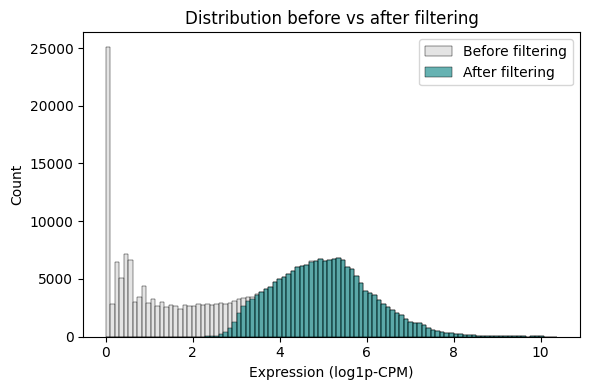

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compare all cell types pooled
fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(df_long["value"], bins=100, label="Before filtering", color="lightgray", alpha=0.6)
sns.histplot(df_filtered["value"], bins=100, label="After filtering", color="teal", alpha=0.6)
plt.legend()
plt.xlabel("Expression (log1p-CPM)")
plt.title("Distribution before vs after filtering")
plt.tight_layout()
plt.show()

In [9]:
import pymc as pm
import arviz as az

def fit_gene_pymc_ac(df_gene, *, advi=False, draws=1000, tune=1000, chains=4,
                     target_accept=0.9, seed=42):
    """
    value ~ age + condition + age:condition + (1|sample)
    df_gene is one (cell_type, gene).
    """
    df = df_gene.copy()
    ages    = sorted(df["age"].astype(str).unique())
    conds   = sorted(df["condition"].astype(str).unique())
    samples = sorted(df["sample_id"].astype(str).unique())

    A = len(ages); C = len(conds); S = len(samples)

    age_idx    = df["age"].astype(str).apply(ages.index).to_numpy()
    cond_idx   = df["condition"].astype(str).apply(conds.index).to_numpy()
    sample_idx = df["sample_id"].astype(str).apply(samples.index).to_numpy()
    y          = df["value"].to_numpy()

    with pm.Model() as m:
        sigma         = pm.HalfNormal("sigma", 0.7)
        sigma_sample  = pm.HalfNormal("sigma_sample", 0.5)
        sample_offset = pm.Normal("sample_offset", 0.0, sigma_sample, shape=S)

        beta_age         = pm.Normal("beta_age", 0.0, 0.5, shape=A)
        beta_cond        = pm.Normal("beta_cond", 0.0, 0.5, shape=C)
        beta_interaction = pm.Normal("beta_interaction", 0.0, 0.5, shape=(A, C))

        mu = (
            beta_age[age_idx]
          + beta_cond[cond_idx]
          + beta_interaction[age_idx, cond_idx]
          + sample_offset[sample_idx]
        )

        pm.Normal("obs", mu, sigma, observed=y)

        if advi:
            approx = pm.fit(20_000, random_seed=seed, progressbar=False)
            idata  = approx.sample(draws)
        else:
            idata = pm.sample(draws=draws, tune=tune, chains=chains,
                              target_accept=target_accept, random_seed=seed,
                              return_inferencedata=True, progressbar=True)

    meta = {"ages": ages, "conds": conds}
    return idata, meta

def _summarize_1d(samples):
    q = np.quantile(samples, [0.025, 0.975])
    return float(samples.mean()), float(q[0]), float(q[1])

def summarize_effects_ac(idata, meta):
    """
    Report:
      - mtDSB_at_age  = (mtDSB - control) at each age
      - age_interaction(old-young) = difference of those contrasts between oldest and youngest age
    """
    ages  = meta["ages"]
    conds = [c.lower() for c in meta["conds"]]

    # indices for control & mtDSB
    i_ctrl = conds.index("control") if "control" in conds else 0
    i_mt   = conds.index("mtdsb")   if "mtdsb"   in conds else (1 if len(conds)>1 else 0)

    beta_cond = idata.posterior["beta_cond"].values.reshape(-1, len(conds))
    beta_int  = idata.posterior["beta_interaction"].values.reshape(-1, len(ages), len(conds))

    rows = []

    # mtDSB effect at each age
    for a, age in enumerate(ages):
        diff = (beta_cond[:, i_mt] - beta_cond[:, i_ctrl]) + (beta_int[:, a, i_mt] - beta_int[:, a, i_ctrl])
        mean, lo, hi = _summarize_1d(diff)
        rows.append({
            "effect": "mtDSB_at_age", "age": age,
            "mean": mean, "hdi_2.5%": lo, "hdi_97.5%": hi,
            "term": f"beta[{age}] (mtDSB effect @ age)"
        })

    # age interaction: oldest – youngest
    if len(ages) >= 2:
        a_lo, a_hi = 0, len(ages)-1
        d_hi = (beta_cond[:, i_mt] - beta_cond[:, i_ctrl]) + (beta_int[:, a_hi, i_mt] - beta_int[:, a_hi, i_ctrl])
        d_lo = (beta_cond[:, i_mt] - beta_cond[:, i_ctrl]) + (beta_int[:, a_lo, i_mt] - beta_int[:, a_lo, i_ctrl])
        ai  = d_hi - d_lo
        mean, lo, hi = _summarize_1d(ai)
        rows.append({
            "effect": "age_interaction", "age": f"{ages[a_hi]}–{ages[a_lo]}",
            "mean": mean, "hdi_2.5%": lo, "hdi_97.5%": hi,
            "term": f"age_interaction({ages[a_hi]} - {ages[a_lo]})"
        })
    return pd.DataFrame(rows)

In [10]:
def fit_many_genes_condition(df_long, genes, celltypes,
                             *, advi=False, draws=1000, tune=1000, chains=4,
                             target_accept=0.9, seed=42):
    rows = []
    for ct in celltypes:
        df_ct = df_long[df_long["cell_class"] == ct]
        for g in genes:
            sub = df_ct[df_ct["gene"] == g]
            if sub.empty:
                continue
            idata, meta = fit_gene_pymc_condition(
                sub, advi=advi, draws=draws, tune=tune,
                chains=chains, target_accept=target_accept, seed=seed
            )
            eff = summarize_condition_effect(idata, meta)
            eff.insert(0, "gene", g)
            eff.insert(0, "cell_class", ct)
            rows.append(eff)
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

In [11]:
import pymc as pm
import numpy as np
import pandas as pd

def fit_gene_pymc_condition(df_gene,
                            advi=False,
                            draws=1000,
                            tune=1000,
                            chains=4,
                            target_accept=0.9,
                            seed=42):
    """
    Bayesian model for mtDSB vs control (condition only).
    """
    y = df_gene["value"].values
    cond = pd.Categorical(df_gene["condition"])
    cond_idx = cond.codes
    C = len(cond.categories)

    with pm.Model() as m:
        alpha = pm.Normal("alpha", 0, 1)
        sigma = pm.HalfNormal("sigma", 0.5)
        beta = pm.Normal("beta", 0, 1, shape=C)

        mu = alpha + beta[cond_idx]
        pm.Normal("obs", mu, sigma, observed=y)

        if advi:
            approx = pm.fit(20000, random_seed=seed)
            idata = approx.sample(draws)
        else:
            idata = pm.sample(
                draws=draws, tune=tune, chains=chains,
                target_accept=target_accept, random_seed=seed,
                return_inferencedata=True, progressbar=True
            )

    return idata, dict(categories=cond.categories.tolist())

In [34]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from tqdm import tqdm

def screen_condition_ols(df_long: pd.DataFrame, cell_type: str,
                         condition_col="condition",
                         value_col="value",
                         sample_col="sample"):
    """
    Fast OLS screen: value ~ 1 + condition (aggregated per sample to avoid pseudorep).
    Returns tidy DF with columns:
      ['gene','cell_class','ols_effect','ols_se','ols_p','n_samples','n_groups']
    """
    d = df_long[df_long["cell_class"] == cell_type].copy()
    if d.empty:
        return pd.DataFrame(columns=["gene","cell_class","ols_effect","ols_se","ols_p","n_samples","n_groups"])

    # aggregate to per-sample means (prevents many per-sample replicates)
    agg = (d
           .groupby(["gene", sample_col, condition_col], as_index=False)[value_col]
           .mean())

    genes = sorted(agg["gene"].unique())
    rows = []
    for g in tqdm(genes, desc=f"Screening (OLS) in {cell_type}"):
        sub = agg[agg["gene"] == g].copy()
        # drop genes with <2 unique samples or single condition
        if sub[sample_col].nunique() < 2 or sub[condition_col].nunique() < 2:
            continue
        X = pd.get_dummies(sub[condition_col], drop_first=True)  # 0/1 for case vs control
        # If your positive level should be mtDSB, ensure categories ordered
        # e.g., sub[condition_col] = pd.Categorical(sub[condition_col], ["control","mtDSB"])
        X = sm.add_constant(X)
        y = sub[value_col].values
        try:
            fit = sm.OLS(y, X).fit()
            # take the single condition coefficient (last column)
            coef_name = [c for c in X.columns if c != "const"][-1]
            beta = fit.params[coef_name]
            se   = fit.bse[coef_name]
            pval = fit.pvalues[coef_name]
            rows.append({
                "gene": g,
                "cell_class": cell_type,
                "ols_effect": float(beta),
                "ols_se": float(se),
                "ols_p": float(pval),
                "n_samples": int(sub[sample_col].nunique()),
                "n_groups": len(sub)
            })
        except Exception:
            # e.g., singular matrix; skip
            continue

    return pd.DataFrame(rows)

In [45]:
from statsmodels.stats.multitest import multipletests

def make_shortlist(screen_df: pd.DataFrame, top_k=300, by="abs_effect",
                   effect_col=None, p_col=None):
    """
    Create a shortlist of genes from a screen DataFrame.
    - by='abs_effect' ranks by |effect|
    - by='fdr' ranks by BH-FDR on p-values
    Auto-detects column names if not provided.
    """
    if screen_df is None or screen_df.empty:
        return []

    df = screen_df.copy()

    # Infer column names if not provided
    if effect_col is None:
        for cand in ["ols_effect","effect","beta","coef","estimate"]:
            if cand in df.columns:
                effect_col = cand; break
    if p_col is None:
        for cand in ["ols_p","p","pval","p_value"]:
            if cand in df.columns:
                p_col = cand; break

    if effect_col is None:
        raise KeyError("No effect column found (looked for ols_effect/effect/beta/coef/estimate).")
    if p_col is None and by == "fdr":
        raise KeyError("No p-value column found (looked for ols_p/p/pval/p_value).")

    # Compute FDR if requested and available
    if p_col and p_col in df.columns:
        df["ols_fdr"] = multipletests(df[p_col].values, method="fdr_bh")[1]
    else:
        df["ols_fdr"] = np.nan

    # Ranking
    if by == "abs_effect":
        df = df.reindex(df[effect_col].abs().sort_values(ascending=False).index)
    elif by == "fdr":
        if "ols_fdr" not in df or df["ols_fdr"].isna().all():
            raise ValueError("FDR selected but p-values were not available to compute it.")
        df = df.sort_values("ols_fdr", ascending=True)
    else:
        raise ValueError("by must be 'abs_effect' or 'fdr'.")

    # Keep top_k unique genes
    out = df.drop_duplicates("gene").head(top_k)
    return out["gene"].tolist()

In [46]:
import pymc as pm
import arviz as az

def fit_gene_pymc_condition(df_gene,
                            advi=False,
                            draws=800, tune=800, chains=2, cores=2,
                            target_accept=0.9, seed=42):
    y = df_gene["value"].values
    cond = pd.Categorical(df_gene["condition"])
    cond_idx = cond.codes
    C = len(cond.categories)

    with pm.Model() as m:
        alpha = pm.Normal("alpha", 0, 1)
        sigma = pm.HalfNormal("sigma", 0.5)
        beta  = pm.Normal("beta", 0, 1, shape=C)   # condition main effects
        mu = alpha + beta[cond_idx]
        pm.Normal("obs", mu, sigma, observed=y)

        if advi:
            approx = pm.fit(20000, random_seed=seed, callbacks=[pm.callbacks.CheckParametersConvergence()])
            idata = approx.sample(draws, random_seed=seed)
        else:
            idata = pm.sample(draws=draws, tune=tune, chains=chains, cores=cores,
                              target_accept=target_accept, random_seed=seed,
                              return_inferencedata=True, progressbar=True)
    return idata, dict(categories=cond.categories.tolist())

def summarize_condition_effect(idata, meta):
    post = az.summary(idata, var_names=["beta"], hdi_prob=0.95).reset_index()
    post = post.rename(columns={"index": "param"})
    post["condition"] = meta["categories"]
    # Keep the mtDSB effect row only (if your categories are ['control','mtDSB'])
    return post

In [47]:
def fit_many_genes_condition(df_long, genes, celltypes,
                             *, advi=False, draws=800, tune=800, chains=2, cores=2,
                             target_accept=0.9, seed=42):
    rows = []
    for ct in celltypes:
        df_ct = df_long[df_long["cell_class"] == ct]
        for g in genes:
            sub = df_ct[df_ct["gene"] == g]
            if sub.empty or sub["condition"].nunique() < 2:
                continue
            idata, meta = fit_gene_pymc_condition(
                sub, advi=advi, draws=draws, tune=tune, chains=chains, cores=cores,
                target_accept=target_accept, seed=seed
            )
            eff = summarize_condition_effect(idata, meta)
            # keep only the mtDSB row if present
            eff = eff[eff["condition"].str.contains("mtDSB", case=False, na=False)]
            eff.insert(0, "gene", g)
            eff.insert(0, "cell_class", ct)
            rows.append(eff)
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

In [48]:
df_filtered

,sample,age,condition,cell_class,gene,value
0,RB4282,60,control,Mature oligodendrocytes,2610035D17Rik,4.598890
1,RB4350,60,control,Mature oligodendrocytes,2610035D17Rik,4.798055
2,RB4401,60,mtDSB,Mature oligodendrocytes,2610035D17Rik,4.939253
3,RB4403,60,mtDSB,Mature oligodendrocytes,2610035D17Rik,4.772352
4,RB4405,60,mtDSB,Mature oligodendrocytes,2610035D17Rik,5.025128
...,...,...,...,...,...,...
186259,RB4627,21,mtDSB,Telencephalon astrocytes,Zzef1,4.998888
186260,RB4630,21,mtDSB,Telencephalon astrocytes,Zzef1,4.851199
186261,RB4653,21,mtDSB,Telencephalon astrocytes,Zzef1,4.982537
186262,RB4658,21,control,Telencephalon astrocytes,Zzef1,4.824230


In [61]:
ct = celltypes_of_interest[0]

In [62]:
df_filtered.cell_class.unique()

array(['Mature oligodendrocytes', 'Microglia', 'Olfactory astrocytes',
       'Oligodendrocytes precursor cells', 'Telencephalon astrocytes'],
      dtype=object)

In [63]:
d = df_filtered[df_filtered["cell_class"] == ct].copy()
print("Rows in this CT:", len(d))
print("Condition counts:", d["condition"].value_counts().to_dict())

cov = (d.groupby(["gene","condition"])["sample"]
         .nunique()
         .unstack(fill_value=0))
# genes with at least 1 sample in both conditions
ok = cov[(cov > 0).all(axis=1)]
print("Genes with ≥1 sample in BOTH conditions:", len(ok))

Rows in this CT: 38460
Condition counts: {'control': 19230, 'mtDSB': 19230}
Genes with ≥1 sample in BOTH conditions: 3205


In [64]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from tqdm import tqdm

def screen_condition_ols(df_long: pd.DataFrame,
                         cell_type: str,
                         condition_col="condition",
                         value_col="value",
                         sample_col="sample",
                         min_total_samples=2,
                         min_conditions=2):
    """
    Fast OLS screen: value ~ 1 + condition (per-sample means).
    Returns columns: ['gene','cell_class','ols_effect','ols_se','ols_p','n_samples','n_groups']
    """
    cols = ["gene","cell_class","ols_effect","ols_se","ols_p","n_samples","n_groups"]
    d = df_long[df_long["cell_class"] == cell_type].copy()
    if d.empty:
        return pd.DataFrame(columns=cols)

    agg = (d.groupby(["gene", sample_col, condition_col], as_index=False)[value_col]
             .mean())

    genes = sorted(agg["gene"].unique())
    out = []

    for g in tqdm(genes, desc=f"Screening (OLS) in {cell_type}"):
        sub = agg[agg["gene"] == g]

        n_total = sub[sample_col].nunique()
        n_cond  = sub[condition_col].nunique()
        if (n_total < min_total_samples) or (n_cond < min_conditions):
            continue

        X = pd.get_dummies(sub[condition_col], drop_first=True)  # 0/1 case vs control
        X = sm.add_constant(X)
        y = sub[value_col].values

        try:
            fit = sm.OLS(y, X).fit()
            coef_name = [c for c in X.columns if c != "const"][-1]
            out.append({
                "gene": g,
                "cell_class": cell_type,
                "ols_effect": float(fit.params.get(coef_name, np.nan)),
                "ols_se":     float(fit.bse.get(coef_name, np.nan)),
                "ols_p":      float(fit.pvalues.get(coef_name, np.nan)),
                "n_samples":  int(n_total),
                "n_groups":   int(len(sub))
            })
        except Exception:
            # singular design etc.
            continue

    return pd.DataFrame(out, columns=cols)

In [75]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from scipy import stats
from tqdm import tqdm

# --- 1) Helpers --------------------------------------------------------------

def _detect_cols(df):
    """Map whatever you have to standard keys we need."""
    cols = {c.lower(): c for c in df.columns}
    def pick(candidates, required=True):
        for c in candidates:
            if c in cols: 
                return cols[c]
        if required:
            raise KeyError(f"Could not find any of columns: {candidates}")
        return None

    return {
        "gene":       pick(["gene"]),
        "cell_class": pick(["cell_class","celltype","cell_type"]),
        "condition":  pick(["condition","cond","group"]),
        "value":      pick(["value","expr","expression","y"]),
        "sample":     pick(["sample","sample_id","donor","subject"])
    }

def _coerce_condition(d, condition_col, positive="mtDSB", reference="control"):
    # ensure only two levels, ordered [reference, positive]
    d = d.copy()
    d[condition_col] = d[condition_col].astype(str).str.strip()
    levels = sorted(d[condition_col].unique().tolist())
    if reference not in levels or positive not in levels:
        raise ValueError(
            f"Condition levels must include '{reference}' and '{positive}'. "
            f"Found: {levels}"
        )
    d[condition_col] = pd.Categorical(d[condition_col], categories=[reference, positive], ordered=True)
    return d

# --- 2) Robust screen --------------------------------------------------------

def screen_condition_ols_robust(df_long: pd.DataFrame, cell_type: str,
                                positive="mtDSB", reference="control",
                                min_total_samples=2, min_conditions=2):
    """
    Robust fast screen of condition effect within a cell type.
    Returns columns: ['gene','cell_class','ols_effect','ols_se','ols_p','n_samples','n_groups','method']
    """
    std = _detect_cols(df_long)
    cols_out = ["gene","cell_class","ols_effect","ols_se","ols_p","n_samples","n_groups","method"]

    # subset cell type (be exact on the string!)
    d = df_long[df_long[std["cell_class"]] == cell_type].copy()
    if d.empty:
        print(f"[screen] No rows for cell type: {cell_type}")
        return pd.DataFrame(columns=cols_out)

    # enforce condition coding (reference vs positive)
    try:
        d = _coerce_condition(d, std["condition"], positive=positive, reference=reference)
    except Exception as e:
        print("[screen] Condition coercion failed:", e)
        return pd.DataFrame(columns=cols_out)

    # per-sample mean to avoid pseudoreplication
    agg = (d.groupby([std["gene"], std["sample"], std["condition"]], as_index=False)[std["value"]]
             .mean()
             .rename(columns={std["value"]:"y"}))

    # quick diagnostics
    print(f"[screen] {cell_type}: rows={len(d)}, agg_rows={len(agg)}")
    print("[screen] condition counts:", d[std["condition"]].value_counts().to_dict())
    print("[screen] unique genes:", agg[std["gene"]].nunique())

    out = []
    genes = agg[std["gene"]].unique().tolist()
    for g in tqdm(genes, desc=f"Screening in {cell_type}"):
        sub = agg[agg[std["gene"]] == g]
        n_total = sub[std["sample"]].nunique()
        n_cond  = sub[std["condition"]].nunique()
        if (n_total < min_total_samples) or (n_cond < min_conditions):
            continue

        # design: y ~ 1 + I(condition == positive)
        X = pd.get_dummies(sub[std["condition"]], drop_first=True)  # column for positive vs reference
        if X.shape[1] == 0:
            # only one level present (shouldn't happen after checks)
            continue
        X = sm.add_constant(X)
        y = sub["y"].values

        # OLS fit; if it fails, fall back to Welch t-test
        try:
            fit = sm.OLS(y, X).fit()
            coef_name = [c for c in X.columns if c != "const"][-1]
            beta = float(fit.params.get(coef_name, np.nan))
            se   = float(fit.bse.get(coef_name, np.nan))
            pval = float(fit.pvalues.get(coef_name, np.nan))
            method = "OLS"
        except Exception:
            # fall back: Welch t-test on per-sample means
            g0 = sub[sub[std["condition"]].astype(str) == reference]["y"].values
            g1 = sub[sub[std["condition"]].astype(str) == positive]["y"].values
            if len(g0) < 1 or len(g1) < 1:
                continue
            beta = float(np.nanmean(g1) - np.nanmean(g0))
            # SE from two-sample stats (rough)
            se = float(np.sqrt(np.nanvar(g0, ddof=1)/max(len(g0),1) + np.nanvar(g1, ddof=1)/max(len(g1),1)))
            pval = float(stats.ttest_ind(g1, g0, equal_var=False, nan_policy="omit").pvalue)
            method = "welch_t"

        out.append({
            "gene": g,
            "cell_class": cell_type,
            "ols_effect": beta,
            "ols_se": se,
            "ols_p": pval,
            "n_samples": int(n_total),
            "n_groups": int(len(sub)),
            "method": method
        })

    res = pd.DataFrame(out, columns=cols_out)
    if res.empty:
        print("[screen] Result is empty after fitting. Check column names and condition balance.")
    return res

In [76]:
# 1) pick the exact name from your data
print(sorted(df_filtered["cell_class"].unique()))
ct = "Oligodendrocytes precursor cells"  # use the exact string from the print

# 2) run robust screen
screen = screen_condition_ols_robust(df_filtered, ct)

print(screen.shape)
print(screen.head())

/var/folders/pm/2253tbm54v36j0l7lhshq73r0000gn/T/ipykernel_67884/3656730826.py:67: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg = (d.groupby([std["gene"], std["sample"], std["condition"]], as_index=False)[std["value"]]


['Mature oligodendrocytes', 'Microglia', 'Olfactory astrocytes', 'Oligodendrocytes precursor cells', 'Telencephalon astrocytes']
[screen] Oligodendrocytes precursor cells: rows=38460, agg_rows=76920
[screen] condition counts: {'control': 19230, 'mtDSB': 19230}
[screen] unique genes: 3205


Screening in Oligodendrocytes precursor cells: 100%|█| 3205/3205 [00:09<00:00, 3

(3205, 8)
            gene                        cell_class  ols_effect    ols_se  \
0  2610035D17Rik  Oligodendrocytes precursor cells    0.037834  0.041855   
1  9630013A20Rik  Oligodendrocytes precursor cells    0.180305  0.074554   
2           Aatf  Oligodendrocytes precursor cells   -0.042968  0.047424   
3          Abca1  Oligodendrocytes precursor cells   -0.005630  0.077003   
4          Abca3  Oligodendrocytes precursor cells    0.008469  0.024092   

      ols_p  n_samples  n_groups   method  
0  0.537514         12        24  welch_t  
1  0.133255         12        24  welch_t  
2  0.541762         12        24  welch_t  
3  0.959799         12        24  welch_t  
4  0.810316         12        24  welch_t  


In [77]:
screen

,gene,cell_class,ols_effect,ols_se,ols_p,n_samples,n_groups,method
0,2610035D17Rik,Oligodendrocytes precursor cells,0.037834,0.041855,0.537514,12,24,welch_t
1,9630013A20Rik,Oligodendrocytes precursor cells,0.180305,0.074554,0.133255,12,24,welch_t
2,Aatf,Oligodendrocytes precursor cells,-0.042968,0.047424,0.541762,12,24,welch_t
3,Abca1,Oligodendrocytes precursor cells,-0.005630,0.077003,0.959799,12,24,welch_t
4,Abca3,Oligodendrocytes precursor cells,0.008469,0.024092,0.810316,12,24,welch_t
...,...,...,...,...,...,...,...,...
3200,Zswim5,Oligodendrocytes precursor cells,-0.012908,0.058695,0.881330,12,24,welch_t
3201,Zswim9,Oligodendrocytes precursor cells,0.017994,0.052216,0.813875,12,24,welch_t
3202,Zup1,Oligodendrocytes precursor cells,0.042489,0.051512,0.580467,12,24,welch_t
3203,Zyx,Oligodendrocytes precursor cells,-0.077096,0.036474,0.165881,12,24,welch_t


In [78]:
from statsmodels.stats.multitest import multipletests

def make_shortlist(screen_df, top_k=300, by="abs_effect"):
    if screen_df is None or screen_df.empty:
        return []
    df = screen_df.copy()
    df["ols_fdr"] = multipletests(df["ols_p"].values, method="fdr_bh")[1]
    if by == "abs_effect":
        df = df.reindex(df["ols_effect"].abs().sort_values(ascending=False).index)
    elif by == "fdr":
        df = df.sort_values("ols_fdr")
    else:
        raise ValueError("by must be 'abs_effect' or 'fdr'")
    return df.drop_duplicates("gene").head(top_k)["gene"].tolist()

shortlist = make_shortlist(screen, top_k=300, by="abs_effect")
print(len(shortlist), "genes in shortlist")

300 genes in shortlist


In [79]:
import pymc as pm
import arviz as az
import pandas as pd

def _ensure_condition_cats(series):
    if "control" in series.unique() and "mtDSB" in series.unique():
        return pd.Categorical(series, categories=["control","mtDSB"])
    return pd.Categorical(series)

def fit_gene_pymc_condition(
    df_gene,
    aggregate_by_sample=True,
    sample_col="sample",          # or "sample_id"
    advi=False,
    draws=800, tune=800, chains=2, cores=2,
    target_accept=0.9, seed=42,
    progressbar=False
):
    dg = df_gene.copy()

    # be forgiving about sample column name
    if aggregate_by_sample and sample_col not in dg.columns:
        if "sample_id" in dg.columns:
            sample_col = "sample_id"
        else:
            aggregate_by_sample = False  # no sample column → skip aggregation

    if aggregate_by_sample:
        dg = (dg.groupby([sample_col, "condition"], as_index=False)
                .agg(value=("value","mean")))

    cond = _ensure_condition_cats(dg["condition"])
    cond_idx = pd.Categorical(cond).codes
    C = len(pd.Categorical(cond).categories)
    y = dg["value"].values

    with pm.Model() as m:
        alpha = pm.Normal("alpha", 0, 1)
        sigma = pm.HalfNormal("sigma", 0.5)
        beta  = pm.Normal("beta", 0, 1, shape=C)   # condition main effects
        mu = alpha + beta[cond_idx]
        pm.Normal("obs", mu, sigma, observed=y)

        if advi:
            approx = pm.fit(
                20_000,
                random_seed=seed,
                callbacks=[pm.callbacks.CheckParametersConvergence()],
                progressbar=progressbar,   # OK here
            )
            idata = approx.sample(draws, random_seed=seed)  # ← NO progressbar kw here
        else:
            idata = pm.sample(
                draws=draws, tune=tune, chains=chains, cores=cores,
                target_accept=target_accept, random_seed=seed,
                return_inferencedata=True, progressbar=progressbar
            )

    return idata, {"categories": list(pd.Categorical(cond).categories)}

def summarize_condition_effect(idata, meta, hdi=0.95):
    s = az.summary(idata, var_names=["beta"], hdi_prob=hdi).reset_index().rename(columns={"index":"param"})
    s["condition"] = meta["categories"]
    if "mtDSB" in s["condition"].values:
        s = s[s["condition"] == "mtDSB"]
    return s

In [80]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

from joblib import Parallel, delayed
import pandas as pd
import numpy as np

def _fit_one_gene_cond(df_long, gene, cell_type, **kwargs):
    sub = df_long[(df_long["cell_class"]==cell_type) & (df_long["gene"]==gene)]
    if sub.empty or sub["condition"].nunique() < 2:
        return None
    # jitter seed so workers don’t reuse identical seeds
    kwargs = {**kwargs, "seed": (kwargs.get("seed", 42) + hash(gene) % 10_000)}
    idata, meta = fit_gene_pymc_condition(sub, **kwargs)
    eff = summarize_condition_effect(idata, meta)
    if eff.empty: 
        return None
    eff.insert(0, "gene", gene)
    eff.insert(0, "cell_class", cell_type)
    return eff

def fit_many_genes_condition_parallel(df_long, genes, celltypes, n_jobs=8, **kwargs):
    out = []
    for ct in celltypes:
        res = Parallel(n_jobs=n_jobs, backend="loky")(
            delayed(_fit_one_gene_cond)(
                df_long, g, ct,
                advi=True, draws=kwargs.get("draws",600), tune=0,
                chains=1, cores=1,                      # ADVI ignores cores
                target_accept=kwargs.get("target_accept",0.9),
                seed=kwargs.get("seed",42),
                aggregate_by_sample=kwargs.get("aggregate_by_sample",True)
            )
            for g in genes
        )
        ct_df = pd.concat([r for r in res if r is not None], ignore_index=True) if any(res) else pd.DataFrame()
        out.append(ct_df)
    return pd.concat([x for x in out if not x.empty], ignore_index=True) if out else pd.DataFrame()

In [81]:
df_filtered = df_filtered.rename(columns={"sample_id": "sample"})

In [82]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

from joblib import Parallel, delayed
import numpy as np

def _fit_one_gene_cond(df_long, gene, cell_type, **kwargs):
    sub = df_long[(df_long["cell_class"]==cell_type) & (df_long["gene"]==gene)]
    if sub.empty or sub["condition"].nunique() < 2:
        return None
    # jitter seed per gene so workers don’t collide
    kwargs = {**kwargs, "seed": (kwargs.get("seed", 42) + (hash(gene) % 10_000))}
    try:
        idata, meta = fit_gene_pymc_condition(sub, **kwargs)
        eff = summarize_condition_effect(idata, meta)
        if eff.empty:
            return None
        eff.insert(0, "gene", gene)
        eff.insert(0, "cell_class", cell_type)
        return eff
    except Exception as e:
        # optional: print(gene, "failed:", e)
        return None

def fit_many_genes_condition_parallel(df_long, genes, celltypes, n_jobs=8, **kwargs):
    out = []
    for ct in celltypes:
        res = Parallel(n_jobs=n_jobs, backend="loky")(
            delayed(_fit_one_gene_cond)(
                df_long, g, ct,
                advi=True,
                draws=kwargs.get("draws",600),
                tune=0, chains=1, cores=1,             # ADVI ignores cores
                target_accept=kwargs.get("target_accept",0.9),
                aggregate_by_sample=kwargs.get("aggregate_by_sample",True),
                sample_col=kwargs.get("sample_col","sample"),   # set to "sample_id" if needed
                progressbar=False
            )
            for g in genes
        )
        ct_df = [r for r in res if r is not None]
        if ct_df:
            out.append(pd.concat(ct_df, ignore_index=True))
    return pd.concat(out, ignore_index=True) if out else pd.DataFrame()

In [83]:
# If your column is 'sample_id', either rename once:
# df_filtered = df_filtered.rename(columns={"sample_id": "sample"})

# …or pass sample_col="sample_id" below:
summary_fast = fit_many_genes_condition_parallel(
    df_filtered,
    genes=shortlist,
    celltypes=celltypes_of_interest,
    n_jobs=8,
    draws=600,
    target_accept=0.9,
    aggregate_by_sample=True,
    sample_col="sample_id"
)



Finished [100%]: Average Loss = 42.724
arviz - WARNING - Shape validation failed: input_shape: (1, 600), minimum_shape: (chains=2, draws=4)
Finished [100%]: Average Loss = 13.893
arviz - WARNING - Shape validation failed: input_shape: (1, 600), minimum_shape: (chains=2, draws=4)
Finished [100%]: Average Loss = 16.247
arviz - WARNING - Shape validation failed: input_shape: (1, 600), minimum_shape: (chains=2, draws=4)
Finished [100%]: Average Loss = 27.196
arviz - WARNING - Shape validation failed: input_shape: (1, 600), minimum_shape: (chains=2, draws=4)
Finished [100%]: Average Loss = 11.723
Finished [100%]: Average Loss = 16.524
arviz - WARNING - Shape validation failed: input_shape: (1, 600), minimum_shape: (chains=2, draws=4)
Finished [100%]: Average Loss = 20.56
arviz - WARNING - Shape validation failed: input_shape: (1, 600), minimum_shape: (chains=2, draws=4)
Finished [100%]: Average Loss = 27.982
arviz - WARNING - Shape validation failed: input_shape: (1, 600), minimum_shape: (c

In [91]:
# rank by |mean|
top_final = (summary_fast
             .sort_values("mean", key=lambda s: s.abs(), ascending=False)
             .groupby("cell_class").head(200)["gene"].unique().tolist())

In [92]:
len(top_final)

200

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_condition_effect_scatter(summary_df, cell_type, top_n=50, save=None):
    # filter one cell type
    d = summary_df[summary_df["cell_class"] == cell_type].copy()
    if d.empty:
        print(f"No data for {cell_type}")
        return

    # keep only mtDSB condition if others are present
    if "condition" in d.columns and d["condition"].nunique() > 1:
        d = d[d["condition"] == "mtDSB"]

    # rank by absolute mean effect
    d["abs_mean"] = d["mean"].abs()
    d = d.sort_values("abs_mean", ascending=False)

    plt.figure(figsize=(6, max(4, 0.25*len(d))))
    sns.scatterplot(data=d, x="mean", y="gene", s=40, color="C0", edgecolor="k", linewidth=0.3)
    # add HDI intervals as horizontal bars
    plt.hlines(y=d["gene"], xmin=d["hdi_2.5%"], xmax=d["hdi_97.5%"],
               color="gray", alpha=0.5, linewidth=2)

    plt.axvline(0, color="k", ls="--", lw=1)
    plt.title(f"{cell_type}\nPosterior mean ± 95% HDI (mtDSB vs control)")
    plt.xlabel("Posterior mean effect")
    plt.ylabel("")
    plt.tight_layout()

    if save:
        plt.savefig(save, dpi=200, bbox_inches="tight")
    plt.show()

In [94]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_top_genes_caterpillar(summary_df, cell_class, genes, save=None):
    d = summary_df[(summary_df["cell_class"] == cell_class) & (summary_df["gene"].isin(genes))].copy()
    if d.empty:
        print(f"No data for {cell_class}")
        return
    
    # sort by mean effect
    d = d.sort_values("mean", ascending=True)
    d["gene"] = pd.Categorical(d["gene"], categories=d["gene"], ordered=True)
    
    plt.figure(figsize=(3, 0.1 * len(d) + 2))
    ax = sns.pointplot(
        data=d, y="gene", x="mean", join=False, color="C0",
        errorbar=None, scale=0.6
    )
    plt.hlines(y=d["gene"], xmin=d["hdi_2.5%"], xmax=d["hdi_97.5%"],
               color="gray", lw=2, alpha=0.6)
    plt.axvline(0, color="k", ls="--", lw=1)
    plt.title(f"{cell_class} — mtDSB effect (posterior mean ± 95% HDI)")
    plt.xlabel("Posterior mean effect")
    plt.tight_layout()
    if save:
        plt.savefig(save, dpi=200, bbox_inches="tight")
    plt.show()

# Example
plot_top_genes_caterpillar(summary_fast, "Mature oligodendrocytes", top_final[0:30])

No data for Mature oligodendrocytes


In [95]:
df_sorted = (
    summary_fast.loc[summary_fast['gene'].isin(top_final)]
    .assign(order=lambda d: pd.Categorical(d['gene'], categories=top_final, ordered=True))
    .sort_values('order')
    .drop(columns='order')
)

In [96]:
df_sorted[df_sorted.gene == 'Serpina3n']

,cell_class,gene,param,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,condition
291,Oligodendrocytes precursor cells,Serpina3n,beta[1],2.2,0.262,1.696,2.719,0.011,0.008,598.0,378.0,NaN,mtDSB


In [104]:
dict(zip(df_sorted.gene, df_sorted['mean']))

{'Mbp': 3.234,
 'Hspa5': 3.1,
 'Mt2': 3.049,
 'Slc6a11': 2.922,
 'Fabp7': 2.866,
 'Gfap': 2.795,
 'Mfsd2a': 2.716,
 'Sgk1': 2.701,
 'Bcl6': 2.692,
 'Tubb3': 2.683,
 'Zbtb16': 2.681,
 'Slc32a1': 2.627,
 'Tsc22d3': 2.627,
 'Id2': 2.625,
 'Mertk': 2.614,
 'Sept4': 2.579,
 'Spry2': 2.577,
 'Mal': 2.532,
 'Gstp1': 2.508,
 'Cldn11': 2.5,
 'Arc': 2.486,
 'Hnrnpdl': 2.47,
 'Igsf11': 2.462,
 'Gng11': 2.449,
 'Gad2': 2.447,
 'Sox5': 2.433,
 'Cldn10': 2.425,
 'Spry4': 2.405,
 'Egr1': 2.403,
 'Spry1': 2.372,
 'Prkcg': 2.35,
 'Egr3': 2.313,
 'Fkbp5': 2.305,
 'Epb41': 2.297,
 'Kcnn2': 2.292,
 'Hes5': 2.285,
 'Sox9': 2.277,
 'Grb10': 2.277,
 'Ermn': 2.257,
 'Sin3b': 2.245,
 'Gpd1': 2.239,
 'Atf5': 2.221,
 'Inpp4b': 2.218,
 'Rtn4r': 2.218,
 'Jade2': 2.215,
 'Kcnh1': 2.209,
 'Serpina3n': 2.2,
 'Slc2a1': 2.189,
 'Kcnh8': 2.186,
 'Mapk7': 2.182,
 'Ccn1': 2.181,
 'Hapln1': 2.175,
 'Rictor': 2.169,
 'Letmd1': 2.159,
 'P2ry12': 2.157,
 'Sgpl1': 2.153,
 'Pbx2': 2.149,
 '9630013A20Rik': 2.137,
 'Sall3': 2.121

In [97]:
print(top_final) 

['Mbp', 'Hspa5', 'Mt2', 'Slc6a11', 'Fabp7', 'Gfap', 'Mfsd2a', 'Sgk1', 'Bcl6', 'Tubb3', 'Zbtb16', 'Slc32a1', 'Tsc22d3', 'Id2', 'Mertk', 'Sept4', 'Spry2', 'Mal', 'Gstp1', 'Cldn11', 'Arc', 'Hnrnpdl', 'Igsf11', 'Gng11', 'Gad2', 'Sox5', 'Cldn10', 'Spry4', 'Egr1', 'Spry1', 'Prkcg', 'Egr3', 'Fkbp5', 'Epb41', 'Kcnn2', 'Hes5', 'Sox9', 'Grb10', 'Ermn', 'Sin3b', 'Gpd1', 'Atf5', 'Inpp4b', 'Rtn4r', 'Jade2', 'Kcnh1', 'Serpina3n', 'Slc2a1', 'Kcnh8', 'Mapk7', 'Ccn1', 'Hapln1', 'Rictor', 'Letmd1', 'P2ry12', 'Sgpl1', 'Pbx2', '9630013A20Rik', 'Sall3', 'Per1', 'Ddit3', 'Apod', 'Gsx1', 'Kcnab3', 'Hes1', 'Il34', 'Dmap1', 'Jag1', 'Litaf', 'Fos', 'Stk11', 'Rab8b', 'Gpc4', 'Cacng2', 'Mgst3', 'Etv6', 'Ar', 'Zfpm2', 'Dync1i1', 'Adora2b', 'Gabra5', 'Dapk1', 'Eya1', 'Bcor', 'Kpna2', 'Pafah1b3', 'Ftsj1', 'Chst8', 'Prkab1', 'Six3', 'Trpv2', 'Chic2', 'Wsb1', 'Gas6', 'Ak4', 'C4b', 'Adm', 'Wee1', 'Irf9', 'Mtus1', 'B3gnt2', 'Rack1', 'Lamp5', 'Mog', 'Hey2', 'Slc6a9', 'Plxna4', 'Sv2c', 'Srrm4', 'Wtip', 'Bmp4', 'Mylk', 'Xr

In [98]:
gene_modules_mtDSB_OL = {
    # --- 1. Core myelin and OL identity ---
    "myelin_identity": {
        "genes": [
            "Cnp", "Mog", "Mag", "Mbp", "Plp1", "Mal", "Ermn", "Ugt8a", 
            "Cldn11", "Stmn4", "Opalin", "Tppp", "Olig2", "Nkx6-2", "Sox8", "Sox21", "Pou3f1"
        ],
        "desc": "Canonical oligodendrocyte and myelin structure genes; reduced under mtDSB stress, suggesting impaired myelin maintenance or dedifferentiation."
    },

    # --- 2. Mitochondrial stress and ISR ---
    "mitochondrial_ISR": {
        "genes": [
            "Atf4", "Atf5", "Ddit3", "Hspa9", "Hspa1a", "Hsph1", "Tfeb",
            "Mt2", "Gstp1", "Hsf1", "Tiparp", "Txnip", "Sesn2", "Rcan1", 
            "Nfe2l1", "Bach2", "Acsl1"
        ],
        "desc": "Integrated stress response and mitochondrial unfolded protein response (UPRmt); driven by ATF4/CHOP and heat shock pathways, with antioxidant and proteostasis activation."
    },

    # --- 3. Oxidative stress and detoxification ---
    "oxidative_stress": {
        "genes": ["Mt2", "Gstp1", "Hspa9", "Hsph1", "Ero1l", "Hspa1a", "Tiparp", "Sesn2", "Txnip"],
        "desc": "Antioxidant and ROS detoxification; redox balancing via metallothionein, glutathione transferases, and stress chaperones."
    },

    # --- 4. Apoptosis and survival signaling ---
    "apoptosis_survival": {
        "genes": ["Bcl2l1", "Bax", "Ddit3", "Atf4", "Traf6", "Fkbp5", "Sgk1", "Mapk8ip1", "Gars", "Rap1a", "Rapgef3"],
        "desc": "Co-activation of pro- and anti-apoptotic programs; adaptation to maintain survival under mitochondrial stress."
    },

    # --- 5. Lipid metabolism and myelin biogenesis ---
    "lipid_metabolism": {
        "genes": ["Fasn", "Lpin1", "Abca1", "Pla2g4a", "Acsl1", "Cyp27a1", "P4hb", "Ugt8a", "Mal", "Cldn11"],
        "desc": "Myelin lipid synthesis and remodeling; indicates metabolic rewiring of membrane production under stress."
    },

    # --- 6. Mitochondrial and metabolic regulation ---
    "metabolic_regulation": {
        "genes": ["Cpox", "Gars", "Yars", "Ero1l", "Cab39l", "Slc6a8", "Sgpl1", "Idi1", "Acsl1", "Nfe2l1", "Tfeb", "Atad3a"],
        "desc": "Mitochondrial translation, redox balance, creatine metabolism, and heme synthesis; broad mitochondrial adaptation."
    },

    # --- 7. Cytoskeletal and morphological remodeling ---
    "cytoskeleton": {
        "genes": ["Sept7", "Coro1c", "Myh9", "Dync1li1", "Anln", "Arhgef28", "Msn", "Flna"],
        "desc": "Cytoskeletal and process retraction genes; indicates morphological changes in stressed oligodendrocytes."
    },

    # --- 8. Transcriptional and nuclear regulators ---
    "transcriptional_regulators": {
        "genes": ["Zbtb16", "Cebpg", "Etv5", "Egr1", "Bcl6", "Arid5b", "Nr1d1", "Klf15", "Bach2", "Nkx6-2", "Sox8", "Sox21", "Pou3f1"],
        "desc": "Transcription factors mediating reprogramming, dedifferentiation, and metabolic stress response."
    },

    # --- 9. ER–Golgi and protein processing ---
    "ER_stress": {
        "genes": ["P4hb", "Calu", "Rcc2", "Wdr5", "Epb41l3", "Lmna", "Cemip2", "Tiparp"],
        "desc": "ER–Golgi stress response and protein processing; overlap with UPR and chromatin remodeling."
    },

    # --- 10. Immune and inflammatory signaling ---
    "immune_signaling": {
        "genes": ["B2m", "H2-D1", "H2-K1", "C4b", "Csf1", "Cd151", "Traf6", "Grn", "Rcan1"],
        "desc": "MHC-I induction and complement signaling; characteristic of immune-reactive oligodendrocytes in inflammatory or degenerative contexts."
    },

    # --- 11. Circadian and metabolic coupling ---
    "circadian_metabolic": {
        "genes": ["Per1", "Per2", "Nr1d1"],
        "desc": "Circadian rhythm and metabolic coupling; disrupted by mitochondrial stress."
    },

    # --- 12. Miscellaneous / emerging candidates ---
    "other_stress_remodeling": {
        "genes": [
            "Vegfa", "Ece1", "Sema6d", "Gfra1", "Serpina3n", "Dll1", "Mdm2", 
            "Epb41l3", "Fgfr1", "Ephb2", "Vcl", "Lgals1", "Pmp22"
        ],
        "desc": "Tissue remodeling, angiogenic, and signaling molecules induced under chronic mitochondrial stress."
    }
}

In [97]:
all_genes_mtDSB = sorted({g for v in gene_modules_mtDSB_OL.values() for g in v["genes"]})

In [98]:
for module, meta in gene_modules_mtDSB_OL.items():
    subset = summary_fast[summary_fast["gene"].isin(meta["genes"])]
    print(module, subset["mean"].mean())

myelin_identity 2.9146
mitochondrial_ISR 2.474176470588235
oxidative_stress 2.562666666666667
apoptosis_survival 2.6682727272727274
lipid_metabolism 2.6438
metabolic_regulation 2.4142500000000005
cytoskeleton 2.51
transcriptional_regulators 2.387846153846154
ER_stress 2.209625
immune_signaling 2.4045555555555556
circadian_metabolic 2.1999999999999997
other_stress_remodeling 2.222923076923077


In [99]:
summary_fast["module"] = summary_fast["gene"].map(gene_to_module)

NameError: name 'gene_to_module' is not defined